# AI'nspired: Reproducible scripts for analyzing experimental results

This notebook contains the scripts used to analyze the experimental results of the paper *"AI'nspired: Evaluating AI-generated vs. web images as sources of design inspiration"*. The analysis consists of three main parts:
1. **Quantitative analysis of design-inspiration similarities**: This part of the analysis focuses on the quantitative comparison of design-inspiration similarities between AI-generated and web images. Using precomputed computer vision similarity scores using color histograms, contrast descriptors, ResNet embeddings, and DINO embeddings, we analyze the distributions of these scores for the two image sources. We also perform statistical tests to determine if there are significant differences between the two distributions.
2. **Analyses of student designer surveys**: This part of the analysis focuses on the survey results from student designers who evaluated their inspirations in two surveys: after web and generative AI inspiration session and after completing the design project. We analyze the survey responses to determine if there are significant differences in the perceived usefulness and novelty of AI-generated vs. web images as sources of design inspiration.
3. **Analyses of expert ratings**: This part of the analysis focuses on the expert ratings of the design projects created by student designers. We analyze the expert ratings to determine if there are significant differences in the perceived quality and novelty of designs inspired by AI-generated vs. web images.

The data anlyses were performed using Python 3.12.4 and relied on the following libraries:

In [30]:
import re

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import patchworklib as pw

from scipy import stats

## Analysis of inspiration similarities

The inspiration source analyses were based on precomputed color, contrast, ResNet, and DINO similarities found in the `AI'inspired image similarities.csv` file.

In [31]:
df = pd.read_csv("csv/final.csv").rename(columns={"Color_Similarity": "Color", 
                                                                       "ResNet_Similarity": "ResNet embedding", 
                                                                       "Dino_Similarity": "DINO embedding", 
                                                                       "Contrast_Similarity": "Contrast",
                                                                       "Source": "Inspiration source",
                                                                       "Metric": "Similarity metric",
                                                                       "Score": "Similarity score"})
metrics = ['Color', 'Contrast', 'ResNet embedding', 'DINO embedding']
df_melted = pd.melt(df, id_vars=['Inspiration source'], value_vars=metrics, var_name='Similarity metric', value_name='Similarity score')

### Similarity score distributions

The code below was used to generate violin plots that show the distributions of similarity scores between final design images and web (pink) and AI (blue) inspirations.

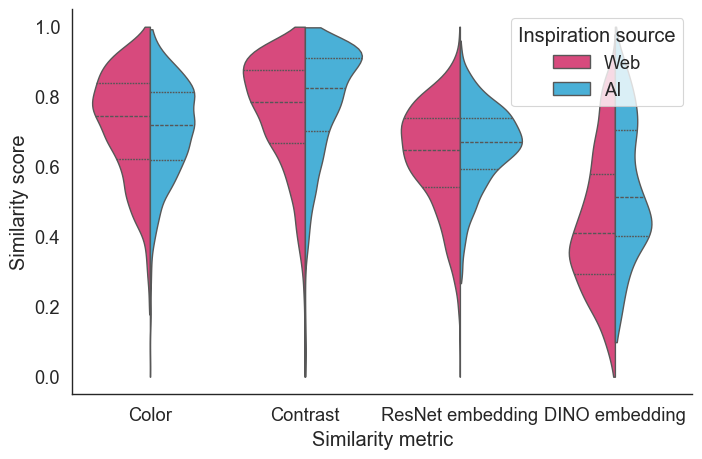

In [32]:
custom_palette = {'AI': '#33BBEE', 'Web': '#EE3377'}
sns.violinplot(data=df_melted, x="Similarity metric", y="Similarity score", hue="Inspiration source", 
               split=True, inner="quart", palette=custom_palette, cut=0, linewidth=1)
sns.despine()
sns.set_context("paper", font_scale=1.5)
sns.set_theme(rc={'figure.figsize': (8, 5)})
sns.set_style("white")
sns.set_style("ticks")

plt.savefig("plots/similarity_plot.svg", format="svg")

### Mood's median test

We also used the median test, to check whether the differences between median similarities to final designs were statistically significantly different between web and AI inspirations.

In [33]:
df_melted.groupby(by=["Similarity metric", "Inspiration source"]).describe()

Similarity score                      \
                                                count      mean       std   
Similarity metric Inspiration source                                        
Color             AI                           2582.0  0.706272  0.138901   
                  Web                          2918.0  0.719048  0.153099   
Contrast          AI                           2582.0  0.787661  0.156442   
                  Web                          2918.0  0.752447  0.161863   
DINO embedding    AI                           2582.0  0.543155  0.194088   
                  Web                          2918.0  0.439500  0.197017   
ResNet embedding  AI                           2582.0  0.660407  0.114505   
                  Web                          2918.0  0.630227  0.148620   

                                                                              \
                                           min       25%       50%       75%   
Similarity metric Inspiration source                                           
Color             AI                  0.000000  0.619099  0.719866  0.813296   
                  Web                 0.178125  0.620996  0.744210  0.838725   
Contrast          AI                  0.000983  0.701285  0.824648  0.911102   
                  Web                 0.000000  0.667501  0.785915  0.876204   
DINO embedding    AI                  0.098729  0.402999  0.513334  0.705276   
                  Web                 0.000000  0.294331  0.411678  0.579675   
ResNet embedding  AI                  0.267453  0.594542  0.671047  0.740302   
                  Web                 0.000000  0.542177  0.648949  0.740271   

                                                
                                           max  
Similarity metric Inspiration source            
Color             AI                  0.992723  
                  Web                 1.000000  
Contrast          AI                  0.998275  
                  Web                 1.000000  
DINO embedding    AI                  1.000000  
                  Web                 0.978378  
ResNet embedding  AI                  0.960237  
                  Web                 1.000000

In [34]:
print(f"Median tests between AI and web similarities")
print("================================")

for metric in metrics:
    print(f"Metric: {metric}")
    print(f"AI median: {df_melted.loc[(df_melted["Inspiration source"] == "AI") & (df_melted["Similarity metric"] == metric) , 'Similarity score'].median():.3f}")
    print(f"Web median: {df_melted.loc[(df_melted["Inspiration source"] == "Web") & (df_melted["Similarity metric"] == metric) , 'Similarity score'].median():.3f}")
    print(f"p-value: {stats.median_test(df_melted.loc[(df_melted["Inspiration source"] == "Web") & (df_melted["Similarity metric"] == metric) , "Similarity score"],
          df_melted.loc[(df_melted["Inspiration source"] == "AI") & (df_melted["Similarity metric"] == metric) , "Similarity score"]).pvalue}")
    print()

Median tests between AI and web similarities
Metric: Color
AI median: 0.720
Web median: 0.744
p-value: 7.638733188237855e-07

Metric: Contrast
AI median: 0.825
Web median: 0.786
p-value: 3.6494173820903757e-13

Metric: ResNet embedding
AI median: 0.671
Web median: 0.649
p-value: 1.8425140814799055e-07

Metric: DINO embedding
AI median: 0.513
Web median: 0.412
p-value: 5.267707396597894e-46



## Designer survey analyses

### Inspiration sources

The first analysis of student surveys presented in the paper is based on surveys performed after the final design project. The survey asked students to which inspiration images were crucial for different design aspects of their final project. The code below was used to generate a stacked bar plot that shows the distribution of inspiration sources for each design aspect.

In [35]:
df_post_survey = pd.read_csv("data/Summary_Survey_PL_EN.csv").iloc[:, [1,3,5,7,9,11,13,15,17]]
df_post_survey.columns = ["Timestamp", "ParticipantID", "Surprise effect", "Innovativeness", "Visual quality", "Scene mood", "Colors", "Materials", "Overall"]
df_post_survey = df_post_survey.iloc[:, 2:]
df_post_survey_cat = df_post_survey.copy()
df_post_survey_cat[df_post_survey <= 10] = "Web" # web inspirations were assigned ids 1-10
df_post_survey_cat[df_post_survey > 10] = "AI" # AI inspirations were assigned ids 11-20
print("Number of surveys: ", df_post_survey.shape[0])
df_post_survey_cat.head()

results = []
total_votes = len(df_post_survey_cat)

for feature in df_post_survey_cat.columns:
    counts = df_post_survey_cat[feature].value_counts()
    web_perc = (counts.get('Web', 0) / total_votes) * 100
    ai_perc = (counts.get('AI', 0) / total_votes) * 100
    results.append({'Feature': feature, 'VoteType': 'Web', 'Percentage': web_perc})
    results.append({'Feature': feature, 'VoteType': 'AI', 'Percentage': ai_perc})

opinion_precentages_df = pd.DataFrame(results)
opinion_precentages_df.head()

Number of surveys:  49


,Feature,VoteType,Percentage
0,Surprise effect,Web,38.775510
1,Surprise effect,AI,61.224490
2,Innovativeness,Web,46.938776
3,Innovativeness,AI,53.061224
4,Visual quality,Web,36.734694


In [36]:
opinion_precentages_df.loc[opinion_precentages_df["Feature"] == "Overall"]

,Feature,VoteType,Percentage
12,Overall,Web,38.77551
13,Overall,AI,61.22449


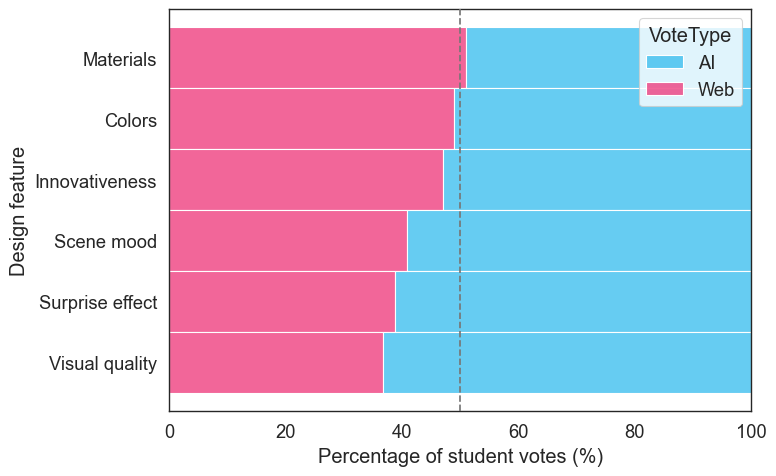

In [37]:
opinion_precentages_df = opinion_precentages_df.loc[opinion_precentages_df["Feature"] != "Overall", :]
web_percentages = opinion_precentages_df[opinion_precentages_df['VoteType'] == 'Web'].set_index('Feature')['Percentage']
sorted_features = web_percentages.sort_values(ascending=False).index.tolist()
opinion_precentages_df['Feature'] = pd.Categorical(opinion_precentages_df['Feature'], categories=sorted_features, ordered=True)
opinion_precentages_df['VoteType'] = pd.Categorical(opinion_precentages_df['VoteType'], categories=["AI", "Web"], ordered=True)
opinion_precentages_df = opinion_precentages_df.sort_values('Feature')


sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.5)
plt.figure(figsize=(8, 5))

# Use seaborn's histplot for easy stacking with weights
ax = sns.histplot(
    data=opinion_precentages_df,
    y='Feature',         
    weights='Percentage',
    hue='VoteType',      
    multiple='stack',    
    palette=custom_palette,
)

plt.xlabel('Percentage of student votes (%)')
plt.ylabel('Design feature')
plt.xlim(0, 100)

ax.axvline(50, color='#777777', linestyle='--', linewidth=1.25, zorder=3)
# sns.move_legend(ax, "upper left", bbox_to_anchor=(1, 1))

plt.tight_layout()
plt.savefig("plots/opinions_plot.svg", format="svg")

### Designer impressions

The second set of survey analyses presented in the paper is based on surveys performed after an inspiration search session. The code below calculates statistics and creates plots that summarize the designers' impressions of the usefulness and novelty of AI-generated vs. web images as sources of design inspiration. In addition to visualizations, we also performed statistical tests to determine if there are significantly different than neutral ratings in AI ease of use and inspiration source usefulness.

In [38]:
df_opinions = pd.read_csv("data/Initial_Survey_PL_EN.csv")
df_opinions = df_opinions.loc[:, df_opinions.columns.str.startswith("[EN]")]
df_opinions = df_opinions.iloc[:, [1,2,3,76,77,78,79,80]]
df_opinions.columns = ["ParticipantID", "Inspiration sites", "Did you use image generative AI before?", "Did any of the AI images spark a new idea?", 
                       "What was most inspiring?", "AI generation ease of use", "Will you use AI for visual inspiration again?", 
                       "Which group of images was more inspiring?"]
df_opinions.to_csv("data/predesign_opinions.csv", index=False)
print(df_opinions.shape[0])
df_opinions.head()

50


,ParticipantID,Inspiration sites,Did you use image generative AI before?,Did any of the AI images spark a new idea?,What was most inspiring?,AI generation ease of use,Will you use AI for visual inspiration again?,Which group of images was more inspiring?
0,1B,Pinterest;Google search,Never before,"Yes, more than one graphic drew my attention t...","The shape and material of the seats, the arran...",4,Rather yes,6
1,7A,Pinterest;Instagram;Behance;Google search,"Yes, a couple of times","Yes, more than one graphic drew my attention t...","Partition between seats, glazing on the arc, s...",4,Rather yes,5
2,2A,Pinterest;Instagram;Behance;Google search,"Yes, a couple of times","No, no graphic drew my attention to a new aspe...",NaN,5,Rather yes,5
3,4A,Pinterest,Never before,"Yes, only one graphic drew my attention to a n...",On the interior layout,4,Rather yes,8
4,2B,Pinterest;Instagram;Google search,"Yes, a couple of times","Yes, more than one graphic drew my attention t...","interesting shapes of the tram, lighting",4,Rather yes,5


#### Statistical test for generative AI ease of use

In [39]:
ease_of_use_ratings = df_opinions['AI generation ease of use'].dropna().values

def rating_tests(ratings, midpoint, ratings_name):
    wilcoxon_result = stats.wilcoxon(ratings - midpoint, alternative='greater')
    
    median_rating = np.median(ratings)
    mean_rating = np.mean(ratings)

    print(f"Statistical tests for {ratings_name}:")
    print(f"Testing whether ratings are different from midpoint ({midpoint})")
    print(f"Median rating: {median_rating}")
    print(f"Mean rating: {mean_rating:.2f}")
    print(f"Sample size: {len(ratings)}")
    
    print(f"\nWilcoxon statistic: {wilcoxon_result.statistic:.2f}")
    print(f"p-value: {wilcoxon_result.pvalue}")
    alpha = 0.05
    if wilcoxon_result.pvalue < alpha:
        direction = "higher" if median_rating > midpoint else "lower"
        print(f"Result: The ease of use ratings are significantly {direction} than the midpoint.")
    else:
        print(f"Result: The ease of use ratings are not significantly different from the midpoint.")
        
rating_tests(ease_of_use_ratings, midpoint=3, ratings_name="AI generation ease of use")

Statistical tests for AI generation ease of use:
Testing whether ratings are different from midpoint (3)
Median rating: 4.0
Mean rating: 4.12
Sample size: 50

Wilcoxon statistic: 658.50
p-value: 5.822210626970294e-08
Result: The ease of use ratings are significantly higher than the midpoint.


#### Statistical test for web versus generative AI inspiration rating

In [40]:
inspiration_ratings = df_opinions['Which group of images was more inspiring?'].dropna().values
rating_tests(inspiration_ratings, midpoint=5, ratings_name="What is more inspiring")

Statistical tests for What is more inspiring:
Testing whether ratings are different from midpoint (5)
Median rating: 6.0
Mean rating: 5.62
Sample size: 50

Wilcoxon statistic: 523.50
p-value: 0.029918971409535398
Result: The ease of use ratings are significantly higher than the midpoint.


#### Survey statistics visualizations

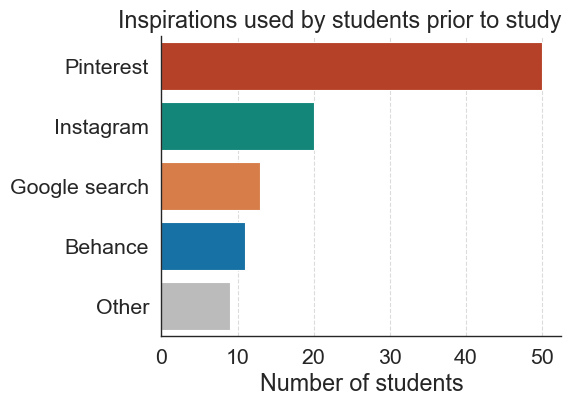

In [41]:
all_sites = []
for sites in df_opinions['Inspiration sites'].dropna():
    site_list = sites.split(';')
    all_sites.extend(site_list)

site_counts = pd.Series(all_sites).value_counts()

threshold = 10
main_sites = site_counts[site_counts >= threshold]
other_count = site_counts[site_counts < threshold].sum()

if other_count > 0:
    final_counts = pd.concat([main_sites, pd.Series({'Other': other_count})])
else:
    final_counts = main_sites

final_counts = final_counts.sort_values(ascending=False)
paul_tol_colors = ["#CC3311",  "#009988", "#EE7733", "#0077BB","#BBBBBB"]

sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.75)

ax1 = pw.Brick(figsize=(4,3))
sns.barplot(y=final_counts.index, x=final_counts.values, palette=paul_tol_colors, ax=ax1)
ax1.set_title('Inspirations used by students prior to study', loc='right')
ax1.set_xlabel('Number of students')
ax1.set_ylabel('')
ax1.grid(axis='x', linestyle='--', alpha=0.7)
sns.despine(ax=ax1)
# ax1.set_index("A")
ax1.savefig("plots/inspiration_sites.svg", format="svg")

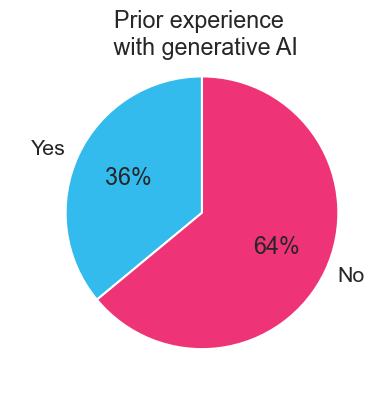

In [42]:
ai_experience_orig = df_opinions['Did you use image generative AI before?'].value_counts()
ai_experience_simplified = {
    'Yes': sum(ai_experience_orig[ai_experience_orig.index.str.contains('Yes')]),
    'No': sum(ai_experience_orig[ai_experience_orig.index.str.contains('Never')])
}
ai_experience_counts = pd.Series(ai_experience_simplified)
custom_colors = {'Yes': '#33BBEE', 'No': '#EE3377'}
colors = [custom_colors[category] for category in ai_experience_counts.index]

ax2 = pw.Brick(figsize=(3,3))
ax2.pie(ai_experience_counts, 
        labels=ai_experience_counts.index,
        autopct='%1.0f%%',
        startangle=90,
        colors=colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

ax2.axis('equal')
ax2.set_title('Prior experience \n with generative AI')
# ax2.set_index("B")
ax2.savefig("plots/ai_experience.svg", format="svg")


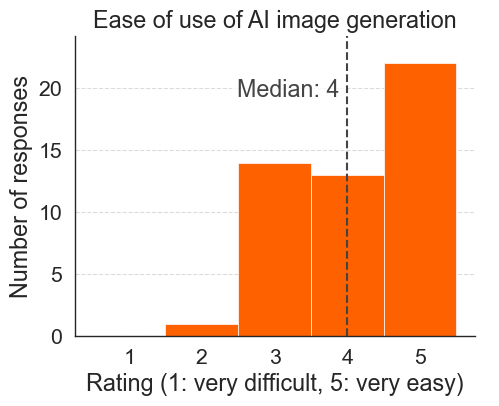

In [43]:
ease_of_use_counts = df_opinions['AI generation ease of use'].value_counts().sort_index()
all_ratings = pd.Series({i: ease_of_use_counts.get(i, 0) for i in range(1, 6)}).sort_index()

ax3 = pw.Brick(figsize=(4,3))
bars = ax3.bar(
    x=all_ratings.index,
    height=all_ratings.values,
    color='#FE6100',
    width=1.0,
    edgecolor='white',
    linewidth=0.5
)

mean_rating = df_opinions['AI generation ease of use'].median()
ax3.axvline(x=mean_rating, color='#444444', linestyle='--', linewidth=1.5)
ax3.text(
    mean_rating - 0.1, 
    max(all_ratings.values) * 0.9,
    f'Median: {mean_rating:.0f}',
    ha='right',
    va='center',
    color='#444444',
    backgroundcolor='white',
    bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.2')
)

ax3.set_xlabel('Rating (1: very difficult, 5: very easy)')
ax3.set_ylabel('Number of responses')
ax3.set_title('Ease of use of AI image generation')
ax3.set_xticks(range(1, 6))  # Show integer values 1-5
ax3.set_ylim(0, max(all_ratings.values) * 1.1)  # Add some space for the label
ax3.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine(ax=ax3)

# ax3.set_index("C")
ax3.savefig("plots/ease_of_use.svg", format="svg")

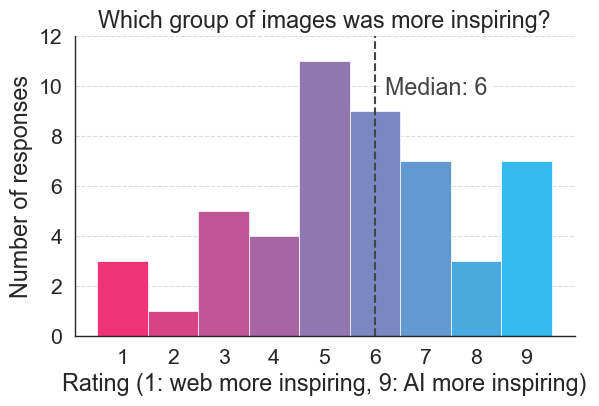

In [44]:
ax4 = pw.Brick(figsize=(5,3))

creativity_ratings = df_opinions['Which group of images was more inspiring?'].value_counts().sort_index()

# Create a color gradient from pink to blue
colors = []
pink = np.array([238, 51, 119])  # #EE3377 in RGB
blue = np.array([51, 187, 238])  # #33BBEE in RGB
for i in range(1, 10):
    factor = (i - 1) / 8
    color_rgb = pink * (1 - factor) + blue * factor
    colors.append('#{:02x}{:02x}{:02x}'.format(int(color_rgb[0]), int(color_rgb[1]), int(color_rgb[2])))

bars = ax4.bar(
    x=creativity_ratings.index,
    height=creativity_ratings.values,
    color=[colors[i-1] for i in creativity_ratings.index],
    width=1.0,  # Full width eliminates spacing
    edgecolor='white',
    linewidth=0.5
)

mean_rating = df_opinions['Which group of images was more inspiring?'].median()
ax4.axvline(x=mean_rating, color='#444444', linestyle='--', linewidth=1.5)
ax4.text(
    mean_rating + 0.2, 
    max(creativity_ratings.values) * 0.9,
    f'Median: {mean_rating:.0f}',
    ha='left',
    va='center',
    color='#444444',
    backgroundcolor='white',
    bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.2')
)


ax4.set_xlabel('Rating (1: web more inspiring, 9: AI more inspiring)')
ax4.set_ylabel('Number of responses')
ax4.set_title('Which group of images was more inspiring?')
ax4.set_xticks(range(1, 10))  # Show integer values 1-9
ax4.set_ylim(0, max(creativity_ratings.values) + 1)  # Add space for labels
ax4.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine(ax=ax4)

# ax4.set_index("D")
ax4.savefig("plots/creativity_ratings.svg", format="svg")

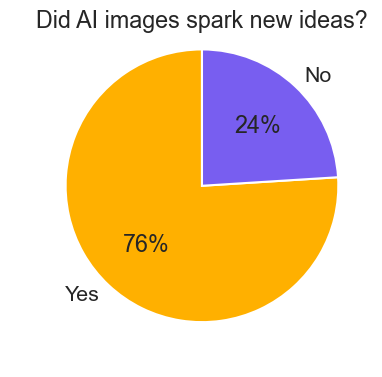

In [45]:
ax5 = pw.Brick(figsize=(3,3))

sparked_ideas = df_opinions['Did any of the AI images spark a new idea?'].value_counts()
sparked_ideas_simplified = {
    'Yes': sum(sparked_ideas[sparked_ideas.index.str.contains('Yes')]),
    'No': sum(sparked_ideas[sparked_ideas.index.str.contains('No')])
}
sparked_ideas_counts = pd.Series(sparked_ideas_simplified)
colors = ['#FFB000', '#785EF0']

ax5.pie(sparked_ideas_counts, 
        labels=sparked_ideas_counts.index,
        autopct='%1.0f%%',
        startangle=90,
        colors=colors,
        wedgeprops={'edgecolor': 'white', 'linewidth': 1.5})

ax5.axis('equal')
ax5.set_title('Did AI images spark new ideas?')
# ax5.set_index("E")

ax5.savefig("plots/sparked_ideas.svg", format="svg")


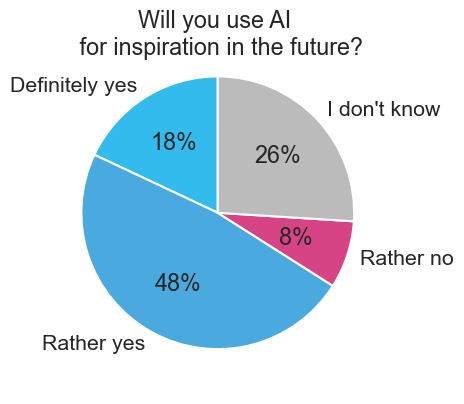

In [46]:
ax6 = pw.Brick(figsize=(3,3))

future_ai_use = df_opinions['Will you use AI for visual inspiration again?'].value_counts()
future_ai_use_simplified = {
    'Definitely yes': future_ai_use['Definitely yes'],
    'Rather yes': future_ai_use['Rather yes'],
    'Rather no': future_ai_use['Rather no'],
    'I don\'t know': future_ai_use['I don\'t know'],
    # 'Definitely not': future_ai_use['Definitely not']
}


future_ai_use_counts = pd.Series(future_ai_use_simplified)
colors = ['#33BBEE', '#4AAADF', '#D64485', '#BBBBBB']  


ax6.pie(
    future_ai_use_counts, 
    labels=future_ai_use_counts.index,
    autopct='%1.0f%%',
    startangle=90,
    colors=colors,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)

ax6.axis('equal')
ax6.set_title('Will you use AI \n for inspiration in the future?')
# ax6.set_index("F")
ax6.savefig("plots/future_ai_use.svg", format="svg")


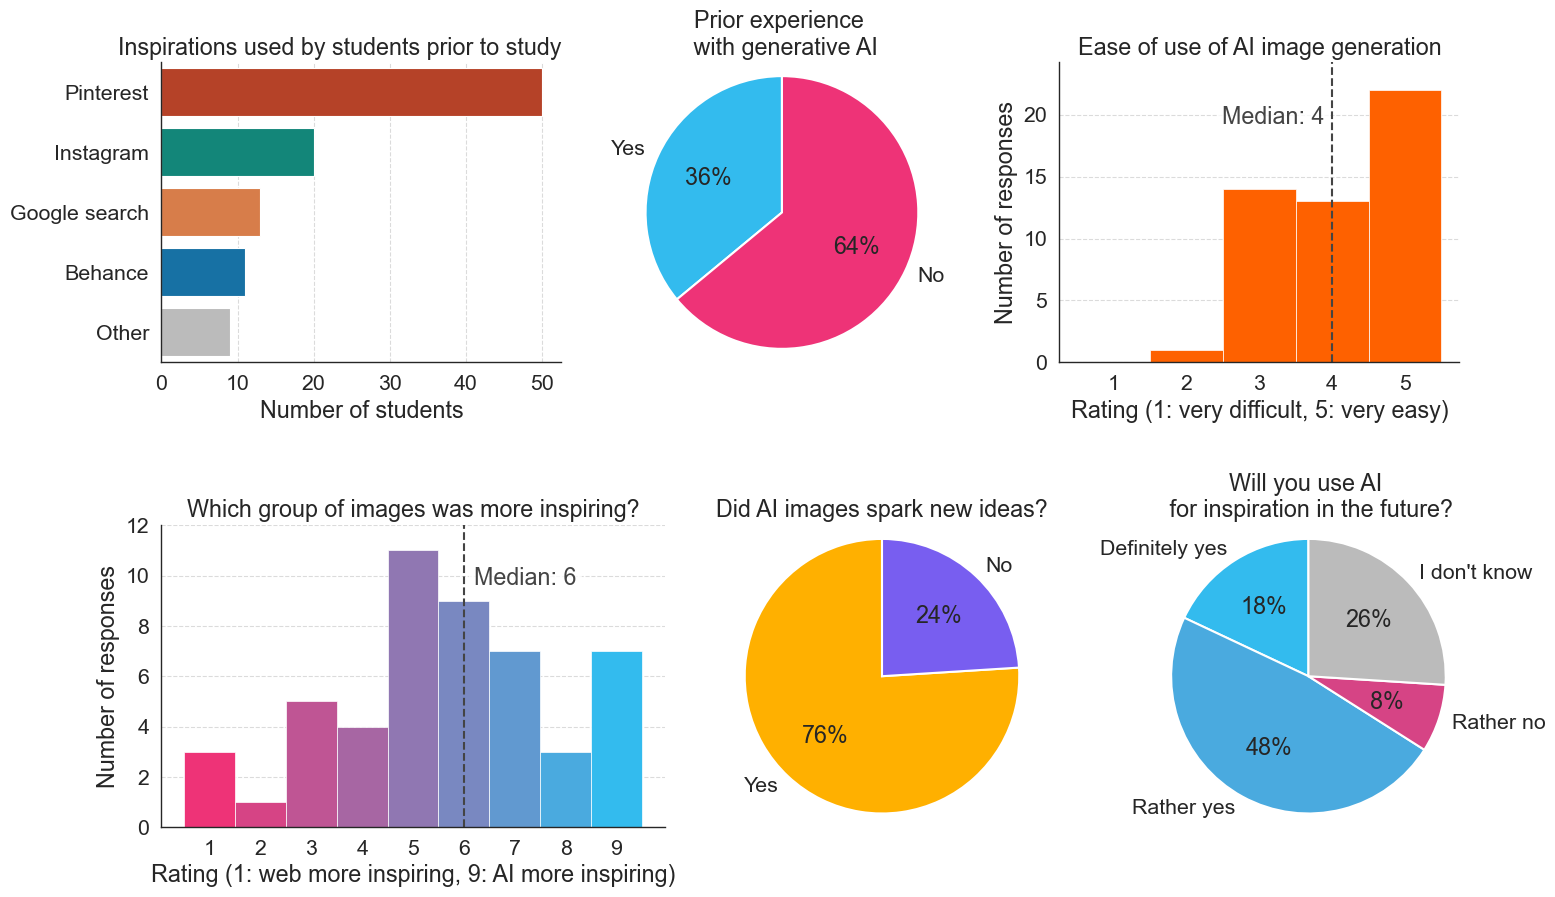

In [47]:
ax12 = (ax1 | ax2 | ax3) / (ax4 | ax5 | ax6)
ax12.savefig("plots/pre_design_survey.svg", format="svg")
ax12.savefig("plots/pre_design_survey.png", format="png", dpi=600)

## Expert ratings

The expert ratings analyses were based on the expert ratings of the final design projects. The code below was used to generate plots that show how often each project was highlighted by experts, the average ratings, and more detailed statistics for projects P18 and P16 which were considered notably different (more inspiring) from the rest.

### Expert ratings data analysis

In [48]:
df_expert = pd.read_csv("data/Expert_Survey_PL_EN.csv")
en_columns = [col for col in df_expert.columns if col.startswith("[EN]")]
df_expert_en = df_expert[en_columns]

highlighted_projects = []
highlighting_column = "[EN] 3.2. If yes, please provide the project number or projects you have highlighted. The file numbers in the OneDrive folder correspond to the project numbers listed in the survey."    

for response in df_expert_en[highlighting_column].dropna():
    response = str(response)
    matches = re.findall(r'(?:Project|no\.?|#)\s*(\d+)', response)
    highlighted_projects.extend(["P"+str(int(num)) for num in matches])

highlight_counts = pd.Series(highlighted_projects).value_counts()
# Add zero to missing projects
missing_projects = [f"P{i}" for i in range(1, 28) if f"P{i}" not in highlight_counts.index]
highlight_counts = pd.concat([highlight_counts, pd.Series(0, index=missing_projects)]).sort_index()

# Rename P27 for presentation purposes as project P26 was missing inspirations and surveys
highlight_counts["P26"] = highlight_counts["P27"] 
highlight_counts.drop("P27", inplace=True)  

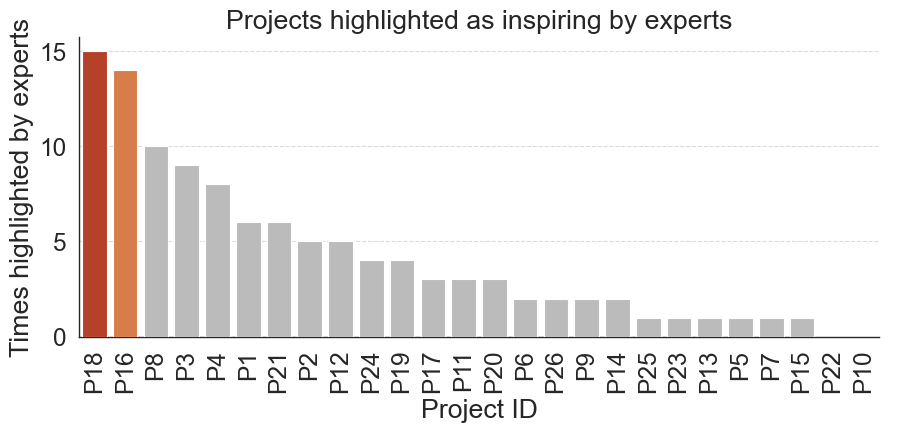

In [49]:
sns.set_theme(style="white")
sns.set_context("paper", font_scale=2)

ax_highlights = pw.Brick(figsize=(8,3))
sorted_counts = highlight_counts.sort_values(ascending=False)
highlights_df = pd.DataFrame({"Project": sorted_counts.index, "Times highlighted": sorted_counts.values})
highlights_df.loc[:, "Special"] = "0"
highlights_df.iloc[0, 2] = "1"
highlights_df.iloc[1, 2] = "2"
# highlights_df.iloc[4, 2] = "3"


colors = ['#CC3311', '#EE7733', '#BBBBBB', '#0077BB']
sns.barplot(
    highlights_df,
    x="Project",
    y="Times highlighted",
    hue="Special",
    palette=colors,
    width=0.8,
    ax=ax_highlights,
    zorder=10,
    alpha=1.0,
    legend=False,
)

ax_highlights.set_title('Projects highlighted as inspiring by experts')
ax_highlights.set_xlabel('Project ID')
ax_highlights.set_ylabel('Times highlighted by experts')
ax_highlights.tick_params(axis='x', rotation=90)
ax_highlights.grid(axis='y', linestyle='--', alpha=0.7)
sns.despine(ax=ax_highlights)
ax_highlights.savefig("plots/highlighted_projects.svg", format="svg")

In [50]:
df_expert = pd.read_csv("data/Expert_Survey_PL_EN.csv")
en_columns = [col for col in df_expert.columns if col.startswith("[EN]")]
df_expert_en = df_expert[en_columns]


stats_data = []

for project_num in range(1, 28):  # Projects 1-27
    patterns = {
        'aesthetics': f'\\[EN\\] 2\\.{project_num}\\.1.*\\[tram aesthetics\\]$',
        'innovativeness': f'\\[EN\\] 2\\.{project_num}\\.1.*\\[solution innovativeness\\]$',
        'project_value': f'\\[EN\\] 2\\.{project_num}\\.1.*\\[project value\\]$',
        'surprisingness': f'\\[EN\\] 2\\.{project_num}\\.2'  # Originality/surprisingness
    }
    
    project_stats = {'project_id': f'P{project_num}'}
    
    for rating_type, pattern in patterns.items():
        matching_cols = [col for col in en_columns if re.search(pattern, col)]
        
        if matching_cols:
            col = matching_cols[0]
            ratings = df_expert_en[col].astype(str)
            ratings = ratings.replace('no opinion / hard to tell', np.nan)
            ratings = ratings.str.extract(r'^(\d+)', expand=False)
            ratings = pd.to_numeric(ratings, errors='coerce')
            
            # Calculate statistics
            project_stats[f'{rating_type}_mean'] = ratings.mean()
            project_stats[f'{rating_type}_median'] = ratings.median()
            project_stats[f'{rating_type}_std'] = ratings.std()
    
    stats_data.append(project_stats)

project_stats_df = pd.DataFrame(stats_data)
project_stats_df.loc[:, "overall_mean"] = project_stats_df.loc[:, ["aesthetics_mean", "innovativeness_mean", "project_value_mean"]].mean(axis=1)
project_stats_df.loc[project_stats_df.project_id == "P27", "project_id"] = "P26" 
project_stats_df = project_stats_df.drop(25)
project_stats_df.tail()


,project_id,aesthetics_mean,aesthetics_median,aesthetics_std,innovativeness_mean,innovativeness_median,innovativeness_std,project_value_mean,project_value_median,project_value_std,surprisingness_mean,surprisingness_median,surprisingness_std,overall_mean
21,P22,2.515152,2.0,1.034445,3.030303,3.0,0.847233,3.030303,3.0,1.074850,2.727273,2.0,1.039012,2.858586
22,P23,2.848485,3.0,1.003781,2.969697,3.0,1.015038,3.181818,3.0,1.014105,2.242424,2.0,0.969223,3.000000
23,P24,3.000000,3.0,1.089725,3.303030,4.0,1.045372,3.212121,3.0,1.023400,2.757576,3.0,0.969223,3.171717
24,P25,2.333333,2.0,1.020621,2.454545,3.0,1.092329,2.562500,3.0,0.981687,2.272727,2.0,0.977008,2.450126
26,P26,2.878788,3.0,1.082750,3.151515,3.0,0.972150,3.090909,3.0,0.842750,2.545455,3.0,1.033529,3.040404


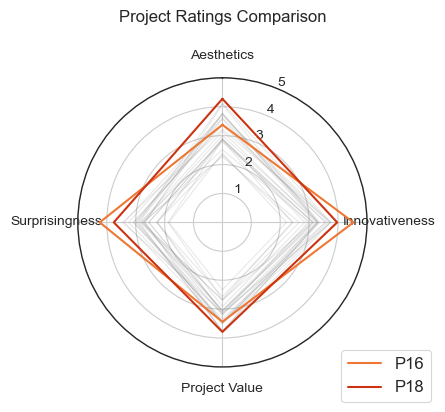

In [51]:
def radar_chart(fig, variables, ranges):
    theta = np.linspace(0, 2*np.pi, len(variables), endpoint=False)
    theta = np.append(theta, theta[0])
    ax = fig.add_subplot(111, projection='polar')
    
    ax.set_theta_offset(np.pi / 2)
    ax.set_theta_direction(-1)
    ax.set_thetagrids(np.degrees(theta[:-1]), variables, fontsize=10)
    ax.set_rlim(0, max(ranges))
    
    # Set explicit grid lines at 1, 2, 3, 4, 5
    tick_positions = [1, 2, 3, 4, 5]
    ax.set_rticks(tick_positions)
    ax.set_yticklabels([f"{int(x)}" for x in tick_positions], fontsize=10)

    return ax, theta


categories = ['aesthetics_mean', 'innovativeness_mean', 'project_value_mean', 'surprisingness_mean']
category_names = ['Aesthetics', 'Innovativeness', 'Project Value', 'Surprisingness']
max_value = 5

fig = plt.figure(figsize=(5, 5))
ax, theta = radar_chart(fig, category_names, [max_value])

project_ids = project_stats_df['project_id'].tolist()
p18_idx = project_ids.index('P18')
p16_idx = project_ids.index('P16')
p4_idx = project_ids.index('P4')
special_indices = [p18_idx, p16_idx, p4_idx]
regular_indices = [i for i in range(len(project_ids)) if i not in special_indices]

for idx in regular_indices:
    values = project_stats_df.iloc[idx][categories].tolist()
    values = np.append(values, values[0])
    ax.plot(theta, values, color='gray', alpha=0.2, linewidth=0.7)

# Plot P16 in orange
p16_values = project_stats_df.iloc[p16_idx][categories].tolist()
p16_values = np.append(p16_values, p16_values[0])
ax.plot(theta, p16_values, color='#EE7733', linewidth=1.5, label="P16")

# Plot P18 in red
p18_values = project_stats_df.iloc[p18_idx][categories].tolist()
p18_values = np.append(p18_values, p18_values[0])
ax.plot(theta, p18_values, color='#CC3311', linewidth=1.5, label="P18")

legend = plt.legend(loc='lower right', bbox_to_anchor=(1.25, -0.15), 
                  fontsize=12, frameon=True, framealpha=0.9)
legend.get_frame().set_facecolor('white')
legend.get_frame().set_edgecolor('lightgray')

plt.title('Project Ratings Comparison', size=12, pad=20)
plt.tight_layout()
plt.savefig('plots/project_ratings_radar.svg', dpi=300, bbox_inches='tight')
plt.show()

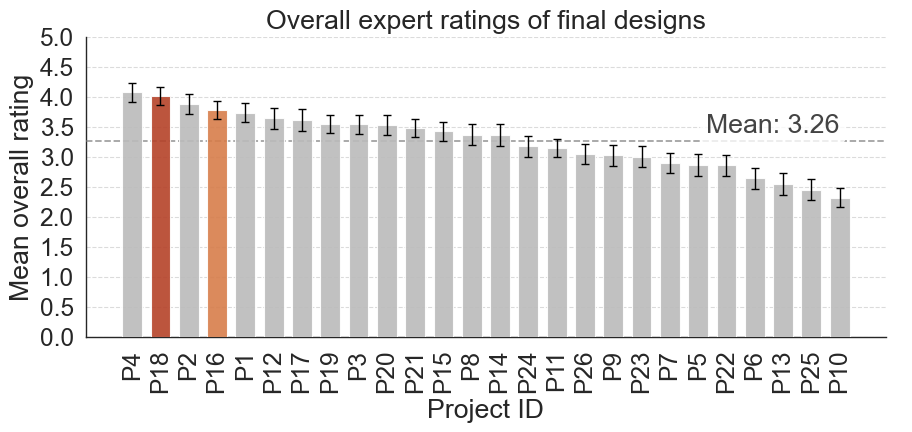

In [52]:
sns.set_theme(style="white")
sns.set_context("paper", font_scale=2)

sorted_projects_df = project_stats_df.sort_values(by='overall_mean', ascending=False).reset_index(drop=True)

ax_ratings = pw.Brick(figsize=(8, 3))
colors = ['#BBBBBB'] * len(sorted_projects_df)
for idx, project_id in enumerate(sorted_projects_df['project_id']):
    if project_id == 'P18':
        colors[idx] = '#CC3311'  # Red
    elif project_id == 'P16':
        colors[idx] = '#EE7733'  # Orange

bars = sns.barplot(
    x="project_id",
    y="overall_mean",
    palette=colors,
    data=sorted_projects_df,
    width=0.7,
    ax=ax_ratings,
    zorder=10,
    alpha=0.9
)

for i, project in enumerate(sorted_projects_df['project_id']):
    project_row = sorted_projects_df.iloc[i]
    avg_std = (project_row['aesthetics_std'] + project_row['innovativeness_std'] + 
              project_row['project_value_std'] + project_row['surprisingness_std']) / 4
    avg_se = avg_std / np.sqrt(len(df_expert_en))
    ax_ratings.errorbar(
        i, project_row['overall_mean'], 
        yerr=avg_se, 
        fmt='none', 
        color='black', 
        capsize=3, 
        linewidth=1, 
        zorder=11
    )

mean_score = sorted_projects_df['overall_mean'].mean()
ax_ratings.axhline(y=mean_score, color='#777777', linestyle='--', linewidth=1.25, zorder=3, alpha=0.7)
ax_ratings.text(
    len(sorted_projects_df) - 1, 
    mean_score + 0.05,
    f'Mean: {mean_score:.2f}',
    ha='right',
    va='bottom',
    color='#444444',
    backgroundcolor='white',
    bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.2')
)

ax_ratings.set_title('Overall expert ratings of final designs')
ax_ratings.set_xlabel('Project ID')
ax_ratings.set_ylabel('Mean overall rating')
ax_ratings.tick_params(axis='x', rotation=90)
ax_ratings.set_ylim(0, 5.0)  # Set y-axis to full scale
ax_ratings.grid(axis='y', linestyle='--', alpha=0.7)
ax_ratings.set_yticks([i/2 for i in range(0, 11)])

sns.despine(ax=ax_ratings)
ax_ratings.savefig("plots/overall_ratings.svg", format="svg")



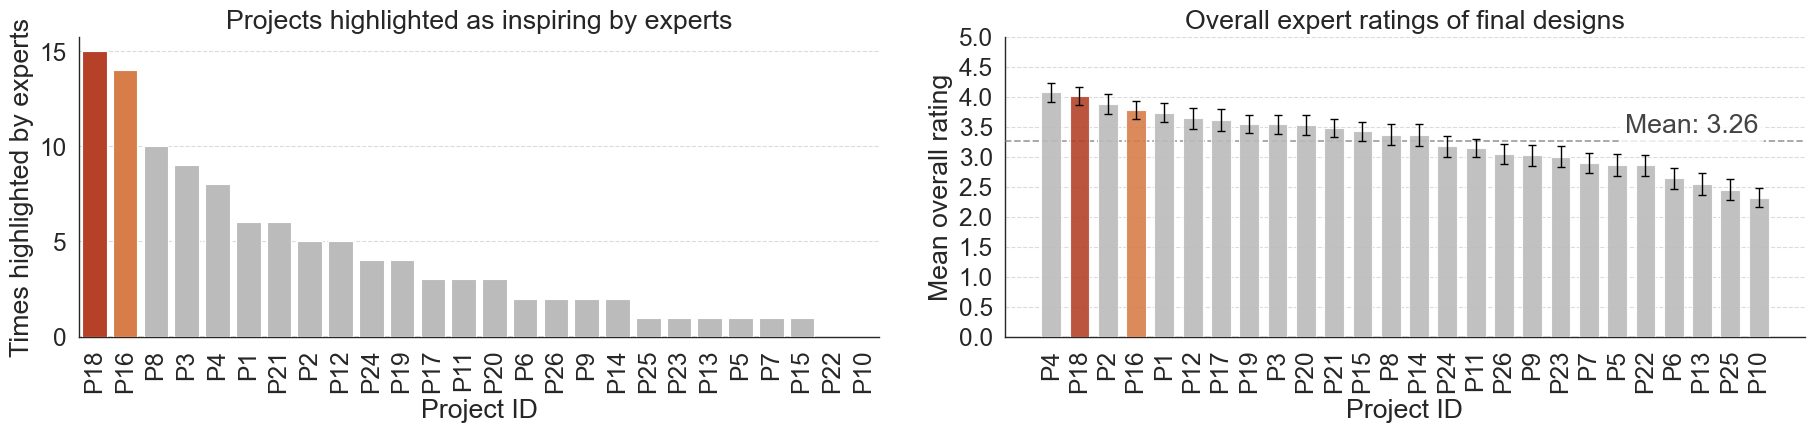

In [53]:
ax_experts = (ax_highlights | ax_ratings)
ax_experts.savefig("plots/expert_survey_tmp.svg", format="svg")

In [54]:
df = pd.read_csv("csv/final.csv")
df['Project'] = "P" + df['Final_Submission'].str.split("_").str[0]
df.head()

,Final_Submission,Inspiration,Dino_Similarity,Color_Similarity,Contrast_Similarity,ResNet_Similarity,Source,Project
0,1_data\1\final\1.png,data\1\web\1A_1.jpg,0.823561,0.494339,0.744526,0.830474,Web,P1
1,1_data\1\final\1.png,data\1\web\1A_10.jpg,0.716302,0.867128,0.624522,0.624924,Web,P1
2,1_data\1\final\1.png,data\1\web\1A_2.jpg,0.370060,0.748430,0.883613,0.638448,Web,P1
3,1_data\1\final\1.png,data\1\web\1A_3.jpg,0.477145,0.718273,0.869075,0.593893,Web,P1
4,1_data\1\final\1.png,data\1\web\1A_4.jpg,0.437572,0.776866,0.813386,0.653300,Web,P1


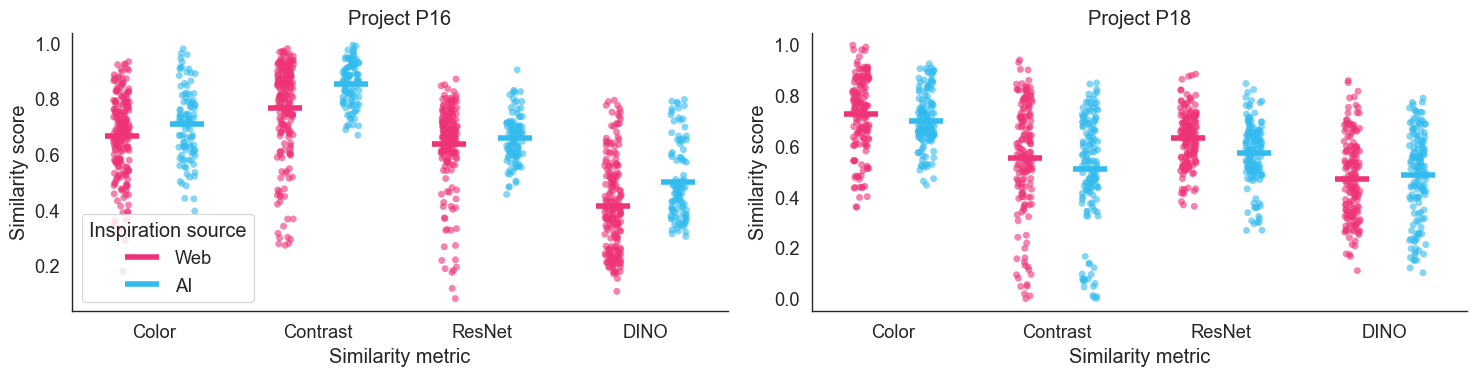

In [55]:
df = pd.read_csv("csv/final.csv")

# Extract project IDs from filenames
df['Project'] = "P" + df['Final_Submission'].str.split("_").str[0]
p16_p18_df = df[df['Project'].isin(['P16', 'P18'])]

sns.set_theme(style="white")
sns.set_context("paper", font_scale=1.5)

fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# P16 plot with strip plot and error bars
similarity_metrics = ['Color_Similarity', 'Contrast_Similarity', 'ResNet_Similarity', 'Dino_Similarity']
p16_data = p16_p18_df[p16_p18_df['Project'] == 'P16'].melt(
    id_vars=['Project', 'Source', 'Final_Submission', 'Inspiration'],
    value_vars=similarity_metrics,
    var_name='Similarity metric',
    value_name='Similarity score'
)

# Strip plot with points showing individual comparisons
sns.stripplot(
    data=p16_data,
    x='Similarity metric',
    y='Similarity score',
    hue='Source',
    palette=custom_palette,
    dodge=True,
    alpha=0.6,
    size=5,
    ax=axes[0], 
    legend=False
)

# Add mean markers
sns.pointplot(
    data=p16_data,
    x='Similarity metric',
    y='Similarity score',
    hue='Source',
    palette=custom_palette,
    dodge=.4, linestyle="none", errorbar=None,
    marker="_", markersize=25, markeredgewidth=4,
    ax=axes[0], 
)

axes[0].set_title('Project P16')
axes[0].set_xticklabels(['Color', 'Contrast', 'ResNet', 'DINO'])
axes[0].legend(title='Inspiration source')

# P18 plot with strip plot and error bars
p18_data = p16_p18_df[p16_p18_df['Project'] == 'P18'].melt(
    id_vars=['Project', 'Source', 'Final_Submission', 'Inspiration'],
    value_vars=similarity_metrics,
    var_name='Similarity metric',
    value_name='Similarity score'
)

# Strip plot with points showing individual comparisons
sns.stripplot(
    data=p18_data,
    x='Similarity metric',
    y='Similarity score',
    hue='Source',
    palette=custom_palette,
    dodge=True,
    alpha=0.6,
    size=5,
    ax=axes[1]
)

# Add mean markers
sns.pointplot(
    data=p18_data,
    x='Similarity metric',
    y='Similarity score',
    hue='Source',
    palette=custom_palette,
    dodge=.4, linestyle="none", errorbar=None,
    marker="_", markersize=25, markeredgewidth=4,
    ax=axes[1]
)

axes[1].set_title('Project P18')
axes[1].set_xticklabels(['Color', 'Contrast', 'ResNet', 'DINO'])
# Remove redundant legend from second subplot
axes[1].legend().set_visible(False)

plt.tight_layout()
sns.despine()

# Save the figure
plt.savefig("plots/ai_web_similarity_stripplot_p16_p18.svg", format="svg")
plt.savefig("plots/ai_web_similarity_stripplot_p16_p18.png", format="png", dpi=300)

### Correlation analysis

We also performed a correlation analysis between expert ratings and levels of similarity to inspirations. We used Spearman's rank correlation to determine if there are significant correlations between the expert ratings and the similarity scores of the final designs to their inspirations.

In [56]:
sim_df = pd.read_csv("csv/final.csv")
sim_df['Group'] = "P" + sim_df['Final_Submission'].str.split('_').str[0]
sim_df.loc[sim_df['Group'] == "P27", "Group"] = "P26"
sim_group_mean = sim_df.groupby(["Group", "Source"])[["Color_Similarity", "ResNet_Similarity", "Contrast_Similarity"]].mean().reset_index()
sim_pivot_mean = sim_group_mean.pivot(index='Group', columns='Source').reset_index()
sim_group_max = sim_df.groupby(["Group", "Source"])[["Dino_Similarity"]].min().reset_index()
sim_pivot_max = sim_group_max.pivot(index='Group', columns='Source').reset_index()

sim_pivot = pd.merge(sim_pivot_mean, sim_pivot_max, left_on="Group", right_on="Group", how="inner")
sim_pivot.reset_index(drop=True, inplace=True)
sim_pivot


Group Color_Similarity           ResNet_Similarity            \
Source                     AI       Web                AI       Web   
0         P1         0.633067  0.780219          0.713771  0.752391   
1        P10         0.749871  0.731624          0.698176  0.680080   
2        P11         0.660443  0.780968          0.572544  0.478485   
3        P12         0.641702  0.674290          0.748439  0.567840   
4        P13         0.730169  0.709510          0.717448  0.615265   
5        P14         0.784133  0.807855          0.649644  0.493331   
6        P15         0.716246  0.750773          0.681642  0.639589   
7        P16         0.707952  0.664918          0.657122  0.636125   
8        P17         0.769933  0.610492          0.771171  0.683161   
9        P18         0.698365  0.723088          0.572740  0.630489   
10       P19         0.553166  0.617502          0.664570  0.588977   
11        P2         0.752774  0.776015          0.583336  0.634566   
12       P20         0.749772  0.693536          0.731304  0.616070   
13       P21         0.604261  0.649910          0.617403  0.571986   
14       P22         0.755697  0.711021          0.755890  0.574855   
15       P23         0.768546  0.675847          0.745307  0.627088   
16       P24         0.839776  0.715061          0.630684  0.678188   
17       P25         0.773454  0.761065          0.686016  0.627107   
18       P26         0.769774  0.758251          0.557823  0.524534   
19        P3         0.772719  0.830429          0.681013  0.716482   
20        P4         0.725134  0.741525          0.612831  0.675423   
21        P5         0.634696  0.685704          0.683343  0.734121   
22        P6         0.750933  0.771629          0.639565  0.655870   
23        P7         0.837271  0.812830          0.767198  0.799315   
24        P8         0.720697  0.710343          0.703450  0.640314   
25        P9         0.799186  0.705646          0.682037  0.657208   

       Contrast_Similarity           Dino_Similarity            
Source                  AI       Web              AI       Web  
0                 0.890878  0.862845        0.388099  0.348159  
1                 0.840575  0.836547        0.213074  0.103885  
2                 0.698578  0.659307        0.136181  0.069908  
3                 0.885784  0.673791        0.384397  0.018166  
4                 0.866003  0.710865        0.274532  0.153975  
5                 0.747259  0.726231        0.173741  0.042679  
6                 0.879264  0.778886        0.383463  0.092967  
7                 0.854203  0.766055        0.304139  0.106252  
8                 0.811457  0.721847        0.397255  0.090796  
9                 0.509528  0.552528        0.101322  0.109603  
10                0.642463  0.785098        0.237514  0.033391  
11                0.816029  0.773095        0.116443  0.104082  
12                0.838777  0.724602        0.369252  0.164877  
13                0.819310  0.720713        0.117987  0.000000  
14                0.880416  0.801210        0.267761  0.124763  
15                0.731766  0.764018        0.280675  0.120965  
16                0.713242  0.786470        0.104704  0.112880  
17                0.626996  0.837384        0.333019  0.158852  
18                0.889363  0.747561        0.098729  0.035634  
19                0.685987  0.743208        0.369609  0.282218  
20                0.880864  0.807624        0.309215  0.227342  
21                0.654553  0.688472        0.361510  0.337037  
22                0.850582  0.786556        0.203821  0.036841  
23                0.914252  0.890855        0.294230  0.273215  
24                0.736982  0.775780        0.333821  0.051775  
25                0.889536  0.827401        0.284943  0.177988

In [57]:
expert_columns = ['aesthetics_mean', 'innovativeness_mean', 'project_value_mean', 'surprisingness_mean']
correlation_results = []
metrics = [('Color_Similarity', 'Web'), ('ResNet_Similarity', 'Web'), ('Contrast_Similarity', 'Web'), 
           ('Dino_Similarity', 'Web'),('Color_Similarity', 'AI'), ('ResNet_Similarity', 'AI'),
           ('Contrast_Similarity', 'AI'), ('Dino_Similarity', 'AI')]
    
for metric, source_type in metrics:
    sim_df = pd.DataFrame(sim_pivot.loc[:, [('Group', ''), (metric, source_type)]].values, columns=["Group", "Similarity"])
    merged_df = pd.merge(sim_df, project_stats_df, left_on="Group", right_on="project_id", how="inner")
    
    for expert_col in expert_columns:
        corr, p_value = stats.spearmanr(
            merged_df['Similarity'],
            merged_df[expert_col],
            alternative='less'
        )
        
        # Add results to our list
        correlation_results.append({
            'Source': source_type,
            'Similarity Metric': metric,
            'Expert Rating': expert_col,
            'Correlation': corr,
            'P-value': p_value,
            'Significant': p_value < 0.05
        })

results_df = pd.DataFrame(correlation_results)
sig_results_df = results_df.loc[results_df['Significant'] == True, :]
sig_results_df = sig_results_df.drop(columns=["Significant"])
sig_results_df = sig_results_df.sort_values(by=["Source", "Similarity Metric", "Expert Rating"])
sig_results_df

,Source,Similarity Metric,Expert Rating,Correlation,P-value
16,AI,Color_Similarity,aesthetics_mean,-0.363543,0.033956
17,AI,Color_Similarity,innovativeness_mean,-0.357632,0.036427
18,AI,Color_Similarity,project_value_mean,-0.338351,0.045448
19,AI,Color_Similarity,surprisingness_mean,-0.424564,0.015315
21,AI,ResNet_Similarity,innovativeness_mean,-0.355921,0.037167
11,Web,Contrast_Similarity,surprisingness_mean,-0.492303,0.005312


### Web-inspired vs AI-inspired project ratings

The final analysis of expert ratings focused on the differences between web-inspired and AI-inspired projects. We used Mood's median  test to determine if there are significant differences in the expert ratings between these two groups of projects.

In [58]:
groups_dict = {}
metric_columns = ['Color_Similarity', 'ResNet_Similarity', 'Contrast_Similarity', 'Dino_Similarity']
expert_columns = ['aesthetics', 'innovativeness', 'project_value', 'surprisingness']

for metric in metric_columns:
    groups_dict["Group"] = sim_pivot["Group"]
    groups_dict[metric] = sim_pivot.loc[:, (metric, "AI")] - sim_pivot.loc[:, (metric, "Web")]
    groups_dict[metric] = groups_dict[metric].apply(lambda x: "AI" if x > 0 else "Web")
    

groups_df = pd.DataFrame(groups_dict)
group_median_results = []

for metric in metric_columns:
    for expert_col in expert_columns:
        
        ai_ratings = []
        web_ratings = []
        
        for project_num in range(1, 28):  # Projects 1-27
            patterns = {
                'aesthetics': f'\\[EN\\] 2\\.{project_num}\\.1.*\\[tram aesthetics\\]$',
                'innovativeness': f'\\[EN\\] 2\\.{project_num}\\.1.*\\[solution innovativeness\\]$',
                'project_value': f'\\[EN\\] 2\\.{project_num}\\.1.*\\[project value\\]$',
                'surprisingness': f'\\[EN\\] 2\\.{project_num}\\.2'  # Originality/surprisingness
            }
            
            matching_cols = [col for col in en_columns if re.search(patterns[expert_col], col)]
            
            if matching_cols:
                col = matching_cols[0]
                ratings = df_expert_en[col].astype(str)
                ratings = ratings.replace('no opinion / hard to tell', np.nan)
                ratings = ratings.str.extract(r'^(\d+)', expand=False)
                ratings = pd.to_numeric(ratings, errors='coerce')
                    
            if project_num == 26:
                continue
            if project_num == 27:
                project_num = 26        
            
            if groups_df.loc[groups_df['Group'] == f'P{project_num}', metric].values[0] == "AI":
                ai_ratings.extend(ratings.values)
            else:
                web_ratings.extend(ratings.values)
                
        
        group_median_results.append({
            'Similarity Metric': metric,
            'Expert Rating': expert_col,
            'AI Median': np.nanmedian(ai_ratings),
            'Web Median': np.nanmedian(web_ratings),
            'AI Mean': np.nanmean(ai_ratings),
            'Web Mean': np.nanmean(web_ratings),
            'p-value': stats.median_test(
                ai_ratings,
                web_ratings,
                nan_policy='omit'
            ).pvalue.round(6)*16 # Bonferroni correction for 16 tests
        })
        
medain_experts_df = pd.DataFrame(group_median_results).sort_values(by=["p-value"])
sig_medain_experts_df = medain_experts_df.loc[medain_experts_df['p-value'] < 0.05, :]
sig_medain_experts_df = sig_medain_experts_df.sort_values(by=["Similarity Metric", "Expert Rating"])
sig_medain_experts_df

,Similarity Metric,Expert Rating,AI Median,Web Median,AI Mean,Web Mean,p-value
0,Color_Similarity,aesthetics,3.0,4.0,2.931925,3.595794,0.000000
1,Color_Similarity,innovativeness,3.0,4.0,3.124706,3.464455,0.001184
2,Color_Similarity,project_value,3.0,3.0,3.070423,3.403302,0.000208
13,Dino_Similarity,innovativeness,3.0,4.0,3.265045,3.636364,0.032544
15,Dino_Similarity,surprisingness,3.0,3.0,2.819444,3.257576,0.039616
4,ResNet_Similarity,aesthetics,3.0,4.0,3.129264,3.518519,0.000080
6,ResNet_Similarity,project_value,3.0,4.0,3.166966,3.368601,0.005632
